In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

from decision_tree import DecisionTree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score



Setting a seed to be able to recreate results

In [2]:
np.random.seed(42)

In [3]:
data = np.genfromtxt("churn-data.csv", delimiter=",", dtype=float, names=True)
feature_names = list(data.dtype.names[:-1])
target_name = data.dtype.names[-1]
X = np.array([data[feature] for feature in feature_names]).T
y = data[target_name].astype(int)

In [4]:
print(f"Feature columns names: {feature_names}")
print(f"Target column name: {target_name}")
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

Feature columns names: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges']
Target column name: Churn
X shape: (7032, 19)
y shape: (7032,)


In [5]:
X_train, X_valtest, y_train, y_valtest = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_valtest, y_valtest, test_size=0.5, random_state=42)


In [6]:
model = DecisionTree(criterion="gini", max_depth=10, root=None)
model2 = DecisionTree(criterion="entropy", max_depth=10, root=None)

In [7]:
root = model.fit(X_val, y_val)
model.print_tree(root, feature_names)

Contract <= 0.670
  Yes:
    TechSupport <= 0.471
      Yes:
        tenure <= 18.582
          Yes:
            InternetService <= 0.605
              Yes:
                tenure <= 5.049
                  Yes:
                    PhoneService <= 0.721
                      Yes:
                        SeniorCitizen <= 0.368
                          Yes:
                            PaperlessBilling <= 0.500
                              Yes:
                                gender <= 0.333
                                  Yes:
                                    Partner <= 0.500
                                      Yes:
                                        Predict: 0
                                      No:
                                        Predict: 1
                                  No:
                                    Predict: 0
                              No:
                                gender <= 0.667
                                  Yes:
                   

In [8]:
root2 = model2.fit(X_val, y_val)
model2.print_tree(root2, feature_names)

Contract <= 0.670
  Yes:
    TechSupport <= 0.471
      Yes:
        tenure <= 18.582
          Yes:
            InternetService <= 0.605
              Yes:
                tenure <= 5.049
                  Yes:
                    PhoneService <= 0.721
                      Yes:
                        SeniorCitizen <= 0.368
                          Yes:
                            DeviceProtection <= 0.333
                              Yes:
                                StreamingTV <= 0.200
                                  Yes:
                                    Dependents <= 0.333
                                      Yes:
                                        Predict: 0
                                      No:
                                        Predict: 1
                                  No:
                                    Predict: 0
                              No:
                                Predict: 1
                          No:
                         

In [9]:
predictions = model.predict(X_val)

In [10]:
predictions2 = model2.predict(X_val)

In [11]:
predictions.count(0), predictions.count(1)

(779, 276)

In [12]:
predictions2.count(0), predictions2.count(1)

(778, 277)

In [13]:
y_true = np.asarray(y_val).ravel()
y_pred = np.asarray(predictions).ravel()  # Use your prediction variable

assert y_true.shape == y_pred.shape

print("Correct:", np.sum(y_pred == y_true))
print("Predicted zeros:", np.sum(y_pred == 0))
print("Actual zeros:", np.sum(y_true == 0))
print("Predicted labels:", np.unique(y_pred, return_counts=True))
print("Correct ones: ", np.sum((y_pred == 1) & y_true == 1))

Correct: 996
Predicted zeros: 779
Actual zeros: 768
Predicted labels: (array([0, 1]), array([779, 276]))
Correct ones:  252


In [14]:
y_true = np.asarray(y_val).ravel()
y_pred_entropy = np.asarray(predictions2).ravel()  # Use your prediction variable

assert y_true.shape == y_pred.shape

print("Correct:", np.sum(y_pred_entropy == y_true))
print("Predicted zeros:", np.sum(y_pred_entropy == 0))
print("Actual zeros:", np.sum(y_true == 0))
print("Predicted labels:", np.unique(y_pred_entropy, return_counts=True))
print("Correct ones: ", np.sum((y_pred_entropy == 1) & y_true == 1))

Correct: 987
Predicted zeros: 778
Actual zeros: 768
Predicted labels: (array([0, 1]), array([778, 277]))
Correct ones:  248


In [15]:
print("Different predictions:", np.sum(y_pred != y_pred_entropy))

Different predictions: 23


In [51]:
models = {
    DecisionTree(criterion="gini", max_depth=1, root=None),
    DecisionTree(criterion="gini", max_depth=2, root=None),
    DecisionTree(criterion="gini", max_depth=3, root=None),
    DecisionTree(criterion="gini", max_depth=4, root=None),
    DecisionTree(criterion="gini", max_depth=5, root=None),
    DecisionTree(criterion="gini", max_depth=6, root=None),
    DecisionTree(criterion="gini", max_depth=8, root=None),
    DecisionTree(criterion="gini", max_depth=10, root=None),
    DecisionTree(criterion="gini", max_depth=20, root=None),
    DecisionTree(criterion="gini", max_depth=40, root=None),
    DecisionTree(criterion="gini", max_depth=None, root=None),
    DecisionTree(criterion="entropy", max_depth=1, root=None),
    DecisionTree(criterion="entropy", max_depth=2, root=None),
    DecisionTree(criterion="entropy", max_depth=3, root=None),
    DecisionTree(criterion="entropy", max_depth=4, root=None),
    DecisionTree(criterion="entropy", max_depth=5, root=None),
    DecisionTree(criterion="entropy", max_depth=6, root=None),
    DecisionTree(criterion="entropy", max_depth=8, root=None),
    DecisionTree(criterion="entropy", max_depth=10, root=None),
    DecisionTree(criterion="entropy", max_depth=20, root=None),
    DecisionTree(criterion="entropy", max_depth=40, root=None),
    DecisionTree(criterion="entropy", max_depth=None, root=None),
}

In [52]:
criteria = {model.criterion for model in models}

# sorted doesn't support nontype, so just did a quick-fix and excluded it 
max_depths = sorted({model.max_depth for model in models if model.max_depth is not None})

print(f"Criteria:   {criteria}")
print(f"Max depths: {max_depths} and None")
print(f"Total models to train: {len(criteria) * len(max_depths) + 2}") # +2 for the max_depth=None

Criteria:   {'entropy', 'gini'}
Max depths: [1, 2, 3, 4, 5, 6, 8, 10, 20, 40] and None
Total models to train: 22


In [53]:
results = []
best_model = None
best_f1 = -1
best_result = None

for model in models:
    model = DecisionTree(criterion=model.criterion, max_depth=model.max_depth, root=None)
    model.fit(X_train, y_train)
    predictions = model.predict(X_val)
    

    acc = accuracy_score(y_val, predictions)
    f1 = f1_score(y_val, predictions, pos_label=1)

    result = {
        "criterion": model.criterion,
        "max_depth": model.max_depth,
        "accuracy": acc,
        "f1_score": f1,
    }
    results.append(result)

    # Storing our best model for further use
    if f1 > best_f1:
        best_f1 = f1
        best_model = model
        best_result = result

    print(f"criterion={model.criterion:8s} max_depth={str(model.max_depth):4s}  accuracy={acc:.4f}  f1={f1:.4f}")

criterion=entropy  max_depth=40    accuracy=0.7166  f1=0.4975
criterion=gini     max_depth=40    accuracy=0.7185  f1=0.5025
criterion=entropy  max_depth=6     accuracy=0.7839  f1=0.5309
criterion=gini     max_depth=6     accuracy=0.7839  f1=0.5309
criterion=gini     max_depth=4     accuracy=0.7858  f1=0.5350
criterion=entropy  max_depth=5     accuracy=0.7962  f1=0.5951
criterion=entropy  max_depth=4     accuracy=0.7858  f1=0.5350
criterion=gini     max_depth=8     accuracy=0.7763  f1=0.5693
criterion=gini     max_depth=3     accuracy=0.7858  f1=0.5350
criterion=entropy  max_depth=20    accuracy=0.7166  f1=0.4975
criterion=entropy  max_depth=2     accuracy=0.7412  f1=0.5687
criterion=gini     max_depth=20    accuracy=0.7185  f1=0.5025
criterion=gini     max_depth=10    accuracy=0.7488  f1=0.5259
criterion=gini     max_depth=1     accuracy=0.7280  f1=0.0000
criterion=entropy  max_depth=8     accuracy=0.7791  f1=0.5771
criterion=gini     max_depth=2     accuracy=0.7412  f1=0.5687
criterio

In [54]:
results_df = pd.DataFrame(results)
results_df_sorted = results_df.sort_values(by=["f1_score", "accuracy"], ascending=False)
results_df_sorted.round(4)

,criterion,max_depth,accuracy,f1_score
5,entropy,5.0,0.7962,0.5951
17,gini,5.0,0.7962,0.5951
14,entropy,8.0,0.7791,0.5771
7,gini,8.0,0.7763,0.5693
10,entropy,2.0,0.7412,0.5687
15,gini,2.0,0.7412,0.5687
4,gini,4.0,0.7858,0.5350
6,entropy,4.0,0.7858,0.5350
8,gini,3.0,0.7858,0.5350
18,entropy,3.0,0.7858,0.5350


In [55]:
print("BEST MODEL:")
print(f"Criterion: {best_model.criterion}")
print(f"Max depth: {best_model.max_depth}")
print(f"Accuracy: {best_result['accuracy']:.4f}")
print(f"F1-score: {best_result['f1_score']:.4f}")

BEST MODEL:
Criterion: entropy
Max depth: 5
Accuracy: 0.7962
F1-score: 0.5951


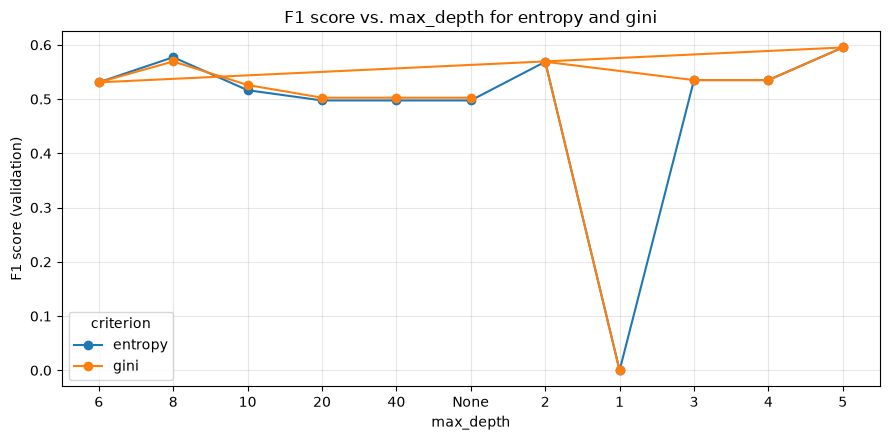

In [43]:
#Generated with ChatGPT, same with all plots


plot_df = results_df.copy()
plot_df['depth_label'] = plot_df['max_depth'].apply(lambda d: 'None' if pd.isna(d) else str(int(d)))

fig, ax = plt.subplots(figsize=(9, 4.5))
for criterion, group in plot_df.groupby('criterion'):
    ax.plot(group['depth_label'], group['f1_score'], marker="o", label=criterion)
ax.set_xlabel('max_depth')
ax.set_ylabel('F1 score (validation)')
ax.set_title('F1 score vs. max_depth for entropy and gini')
ax.legend(title='criterion')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Flere plot for å sammenligne dybder og modeller

Under her ser vi på det samme resultatet fra flere vinkler: accuracy vs. dybde, om modellene overfitter ved høy dybde, og hvordan den beste modellen faktisk generaliserer til det uberørte test-settet.

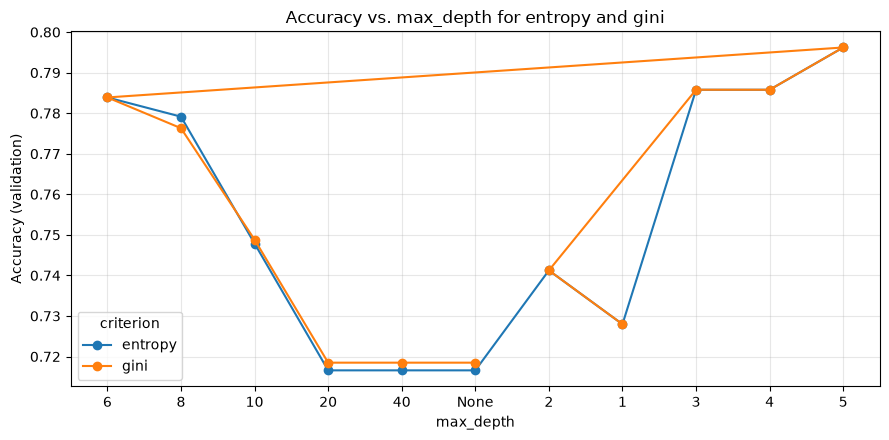

In [44]:
fig, ax = plt.subplots(figsize=(9, 4.5))
for criterion, group in plot_df.groupby('criterion'):
    ax.plot(group['depth_label'], group['accuracy'], marker="o", label=criterion)
ax.set_xlabel('max_depth')
ax.set_ylabel('Accuracy (validation)')
ax.set_title('Accuracy vs. max_depth for entropy and gini')
ax.legend(title='criterion')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Merk:** ved `max_depth=1` er accuracy relativt høy (0.728), men F1-scoren er 0.0. Det er fordi treet da bare gjetter "ingen churn" på alt (den vanligste klassen), noe som gir høy accuracy på et ubalansert datasett uten å faktisk fange opp churn-kundene. Dette viser hvorfor F1-score er et bedre mål enn accuracy her.

### Overfitting: trenings-accuracy vs. validerings-accuracy

For å se om høy `max_depth` fører til overfitting, trener vi samme modeller igjen og sammenligner accuracy på treningssettet med accuracy på valideringssettet.

In [58]:
overfit_results = []

for model in models:
    model = DecisionTree(criterion=model.criterion, max_depth=model.max_depth, root=None)
    model.fit(X_train, y_train)

    train_acc = accuracy_score(y_train, model.predict(X_train))
    val_acc = accuracy_score(y_val, model.predict(X_val))

    overfit_results.append({
        'criterion': model.criterion,
        'max_depth': model.max_depth,
        'train_accuracy': train_acc,
        'val_accuracy': val_acc,
    })

overfit_df = pd.DataFrame(overfit_results)
overfit_df['depth_label'] = overfit_df['max_depth'].apply(lambda d: 'None' if pd.isna(d) else str(int(d)))
overfit_df.round(4).sort_values(['max_depth']).head(5)

,criterion,max_depth,train_accuracy,val_accuracy,depth_label
16,entropy,1.0,0.7343,0.7280,1
13,gini,1.0,0.7343,0.7280,1
10,entropy,2.0,0.7574,0.7412,2
15,gini,2.0,0.7574,0.7412,2
8,gini,3.0,0.7879,0.7858,3


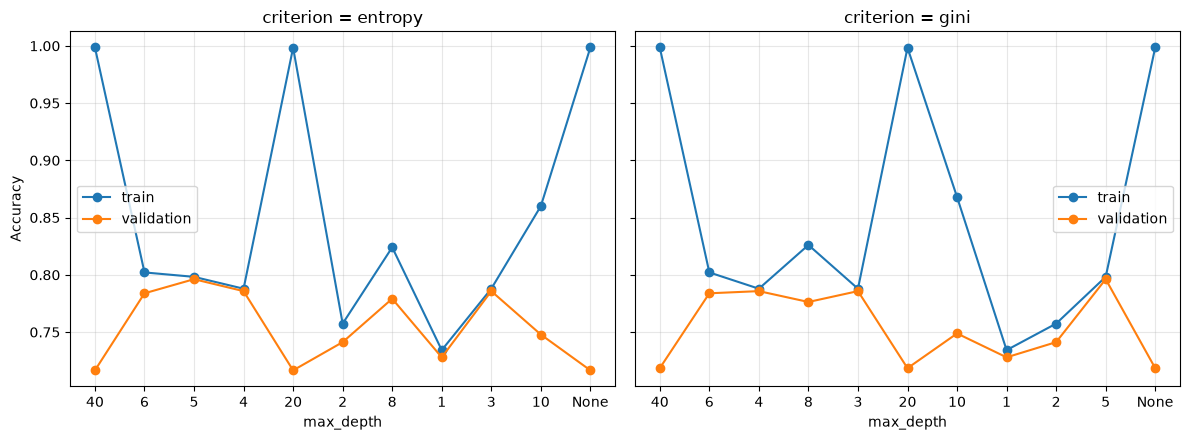

In [59]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)

for ax, (criterion, group) in zip(axes, overfit_df.groupby('criterion')):
    ax.plot(group['depth_label'], group["train_accuracy"], marker='o', label='train')
    ax.plot(group['depth_label'], group["val_accuracy"], marker='o', label='validation')
    ax.set_title(f'criterion = {criterion}')
    ax.set_xlabel('max_depth')
    ax.grid(alpha=0.3)
    ax.legend()

axes[0].set_ylabel('Accuracy')
plt.tight_layout()
plt.show()

### Beste modell mot det uberørte test-settet

Til nå har `X_test`/`y_test` ikke blitt brukt til noe. Vi trener den beste konfigurasjonen (fra `best`) på treningssettet og evaluerer den én gang på test-settet, for å se om resultatet vårt faktisk generaliserer.

criterion=gini, max_depth=5
Test accuracy: 0.7782
Test F1 score: 0.5375


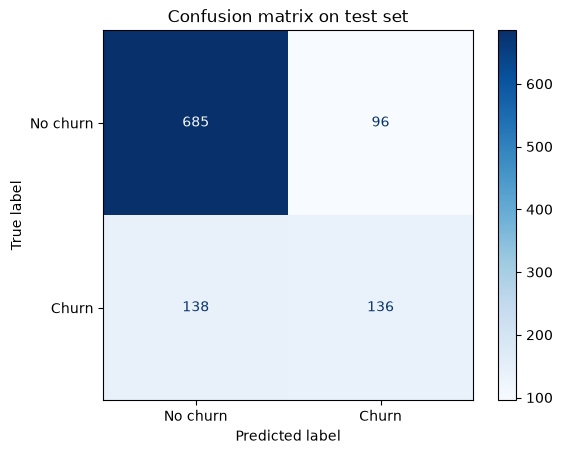

In [61]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

test_predictions = best_model.predict(X_test)

test_acc = accuracy_score(y_test, test_predictions)
test_f1 = f1_score(y_test, test_predictions, pos_label=1)
print(f'criterion={best_model.criterion}, max_depth={best_model.max_depth}')
print(f'Test accuracy: {test_acc:.4f}')
print(f'Test F1 score: {test_f1:.4f}')

cm = confusion_matrix(y_test, test_predictions)
disp = ConfusionMatrixDisplay(cm, display_labels=['No churn', 'Churn'])
disp.plot(cmap='Blues')
plt.title('Confusion matrix on test set')
plt.show()